In [2]:
import numpy as np
import h5py
import pickle
from colossus.lss import peaks
from colossus.cosmology import cosmology

Illustris API request function


In [10]:
import requests
import time

baseUrl = 'http://www.tng-project.org/api/'
headers = {"api-key":"c489f7f5a9e0e61f5060fd16e9fb975e"}

data_dir = './illustris_data/'

def get(path, params=None):
    max_retry = 10

    # make HTTP GET request to path
    for n in range(max_retry):
        try:
            r = requests.get(path, params=params, headers=headers)
            # raise exception if response code is not HTTP SUCCESS (200)
            r.raise_for_status()
            break
        except requests.HTTPError:
            if n < max_retry-1:
                time.sleep(min(2**n, 30))
                continue
            else:
                raise TimeoutError()

    if r.headers['content-type'] == 'application/json':
        return r.json() # parse json responses automatically

    if 'content-disposition' in r.headers:
        filename = data_dir + r.headers['content-disposition'].split("filename=")[1]
        with open(filename, 'wb') as f:
            f.write(r.content)
        f.close()
        return filename # return the filename string

    return r

In [5]:
cosmo = cosmology.setCosmology('planck18')
h=cosmo.h

# Constants
k_B   = 1.381e-16    # erg/K
c_cgs = 2.998e10     # cm/s
eV    = 1.602e-12    # erg
keV   = 1.0e3 * eV   # erg
T_CMB = 2.725        # K
Mpc_cm = 3.086e24    # cm per Mpc

m_wdm = 1.0 * keV    # rest-mass energy of the WDM particle [erg]
z_nr = m_wdm/(k_B * T_CMB) - 1
print(z_nr)
t_nr = 1318860.210  # seconds (age of the Universe at z_nr) (From Ned Wright's cosmology calculator)


lambda_fs_cm = c_cgs * t_nr * (1 + z_nr)
lambda_fs_Mpc = lambda_fs_cm/Mpc_cm
#lambda_fs = 2 # Mpc/h; characteristic free-streaming length for m_wdm=1keV, per [Andrew J. Long and Moira Venegas JCAP06(2025)043] 
M_suppressed = peaks.lagrangianM(lambda_fs_Mpc/h) # In units of M_sun/h
print(f"{M_suppressed:.3e}")

4256986.025755835
1.895e+08


In [6]:
def fs_suppress(primary_halo):
    """Remove subhalos from primary_halo that are below the WDM free-streaming suppression mass cutoff."""
    subhalos = get(primary_halo['meta']['url'],{'limit':primary_halo['child_subhalos']['count']})
    subhalo_list = subhalos['child_subhalos']['results']

    print(f"Group has {len(subhalo_list)} subhalos")
    n_suppressed = 0

    for i in reversed(range(len(subhalo_list))):
        subhalo = get(subhalo_list[i]['url'])
        subhalo_mass = subhalo['mass'] * 10e10 # In units of M_sun/h
        
        if subhalo_mass < M_suppressed:
            del subhalo_list[i]
            n_suppressed+=1

    print(f"{n_suppressed} subhalos suppressed by WDM free streaming")

    return subhalo_list
    

In [12]:
sim = get(baseUrl+'TNG50-1/')
snaps = get(sim['snapshots'])
primary_halo = get(snaps[-1]['url']+f'halos/59/')

In [ ]:
for halo_index in range(77,100):
    primary_halo = get(snaps[-1]['url']+f'halos/{halo_index}/')
    wdm_subhalos = fs_suppress(primary_halo)
    with open(f'./illustris_data/suppression/halo{halo_index}_wdm_fs_sup.pkl','wb') as file:
        pickle.dump(wdm_subhalos, file)

Group has 1067 subhalos
426 subhalos suppressed by WDM free streaming
Group has 1396 subhalos
615 subhalos suppressed by WDM free streaming
Group has 1180 subhalos
494 subhalos suppressed by WDM free streaming
Group has 1216 subhalos
477 subhalos suppressed by WDM free streaming
Group has 951 subhalos
403 subhalos suppressed by WDM free streaming
Group has 1308 subhalos
581 subhalos suppressed by WDM free streaming
Group has 1302 subhalos
568 subhalos suppressed by WDM free streaming
Group has 1340 subhalos
598 subhalos suppressed by WDM free streaming
Group has 1085 subhalos
462 subhalos suppressed by WDM free streaming
Group has 1492 subhalos
658 subhalos suppressed by WDM free streaming
Group has 1039 subhalos
429 subhalos suppressed by WDM free streaming
Group has 1249 subhalos
497 subhalos suppressed by WDM free streaming
Group has 916 subhalos
417 subhalos suppressed by WDM free streaming
Group has 828 subhalos
340 subhalos suppressed by WDM free streaming
Group has 1258 subhalos

In [7]:
from stream_perturbing_halos import code_length_to_kpc, code_mass_to_msun, HALO_CACHE_DIR, BASE_URL
from concurrent.futures import ThreadPoolExecutor, as_completed

def fetch_subhalos(
    halo_idx: int,
    subhalo_cat: list,
    mass_range_msun=(M_suppressed, 1.0e9),
    n_workers: int = 8,
    verbose: bool = True,
) -> dict:
    """
    Fetch all subhalos in mass_range_msun for FoF group halo_idx. Caches the
    result to illustris_data/halos/halo_<idx>.npz so subsequent calls are
    instant.

    Returns a dict with arrays:
        id          : (N,) int64
        mass_msun   : (N,) float
        pos_kpc     : (N, 3) float, simulation-box coordinates [physical kpc]
        R_kpc       : (N,) float, distance to host center [physical kpc]
        halo_pos_kpc: (3,) float, host center position
    """
    cache = HALO_CACHE_DIR / f"halo_{halo_idx}.npz"
    if cache.exists():
        d = np.load(cache)
        return {k: d[k] for k in d.files}

    halo = get(f"{BASE_URL}halos/{halo_idx}/")
    info = get(halo["meta"]["info"])
    halo_pos = code_length_to_kpc(np.array(info["GroupPos"], dtype=float))

    
    urls = [s["url"] for s in subhalo_cat]

    if verbose:
        print(f"halo {halo_idx}: fetching {len(urls)} subhalos...")

    # Concurrent per-subhalo fetches. `get` is cached, so re-fetches are free.
    results = [None] * len(urls)
    with ThreadPoolExecutor(max_workers=n_workers) as ex:
        future_to_i = {ex.submit(get, u): i for i, u in enumerate(urls)}
        done = 0
        for fut in as_completed(future_to_i):
            i = future_to_i[fut]
            results[i] = fut.result()
            done += 1
            if verbose and done % 250 == 0:
                print(f"  halo {halo_idx}: {done}/{len(urls)} fetched")

    ids = np.array([d["id"] for d in results], dtype=np.int64)
    mass_code = np.array([d["mass"] for d in results], dtype=float)
    pos_code = np.array(
        [[d["pos_x"], d["pos_y"], d["pos_z"]] for d in results], dtype=float
    )
    mass_msun = code_mass_to_msun(mass_code)
    pos_kpc = code_length_to_kpc(pos_code)
    R_kpc = np.linalg.norm(pos_kpc - halo_pos, axis=1)

    HALO_CACHE_DIR.mkdir(parents=True, exist_ok=True)
    np.savez(
        cache,
        id=ids,
        mass_msun=mass_msun,
        pos_kpc=pos_kpc,
        R_kpc=R_kpc,
        halo_pos_kpc=halo_pos,
    )
    return {
        "id": ids,
        "mass_msun": mass_msun,
        "pos_kpc": pos_kpc,
        "R_kpc": R_kpc,
        "halo_pos_kpc": halo_pos,
    }

In [12]:
subcat = pickle.load(open(f'illustris_data/suppression/halo77_wdm_fs_sup.pkl','rb'))

sh = fetch_subhalos(77, subcat)
for k, v in sh.items():
    print(
        f"  {k:14s} shape={getattr(v, 'shape', None)} dtype={getattr(v, 'dtype', None)}"
    )

print(f"\nN subhalos in [1e6, 1e9] Msun: {len(sh['id'])}")
print(f"M range: {sh['mass_msun'].min():.2e} to {sh['mass_msun'].max():.2e} Msun")
print(f"R range: {sh['R_kpc'].min():.2f} to {sh['R_kpc'].max():.2f} kpc")
print(f"halo center (sim coords): {sh['halo_pos_kpc']}")

halo 77: fetching 734 subhalos...
  halo 77: 250/734 fetched
  halo 77: 500/734 fetched
  id             shape=(734,) dtype=int64
  mass_msun      shape=(734,) dtype=float64
  pos_kpc        shape=(734, 3) dtype=float64
  R_kpc          shape=(734,) dtype=float64
  halo_pos_kpc   shape=(3,) dtype=float64

N subhalos in [1e6, 1e9] Msun: 734
M range: 2.09e+07 to 2.00e+12 Msun
R range: 0.07 to 1537.80 kpc
halo center (sim coords): [19701.51267715 45124.69264375 31624.49600495]


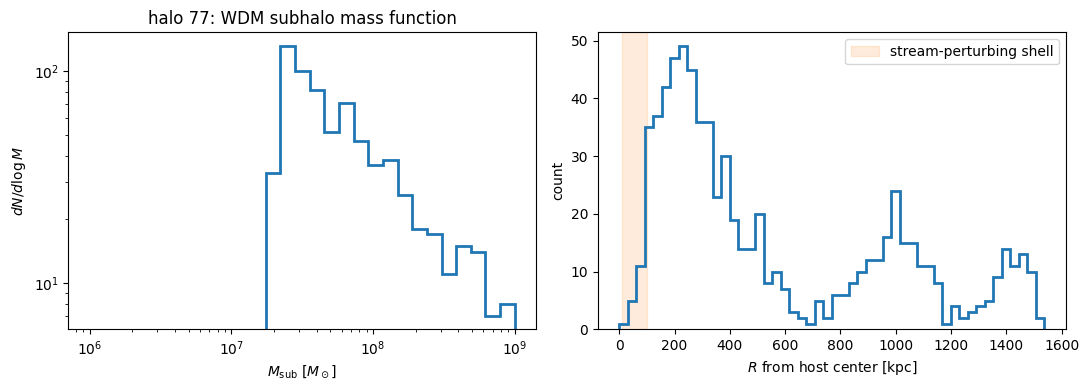

In [13]:
import matplotlib.pyplot as plt
from stream_perturbing_halos import PERTURBER_R_RANGE_KPC

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Mass function
mbins = np.logspace(6, 9, 30)
axes[0].hist(sh["mass_msun"], bins=mbins, histtype="step", lw=2)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel(r"$M_{\rm sub}\ [M_\odot]$")
axes[0].set_ylabel(r"$dN/d\log M$")
axes[0].set_title(f"halo 77: WDM subhalo mass function")

# Radial distribution
axes[1].hist(sh["R_kpc"], bins=50, histtype="step", lw=2)
axes[1].axvspan(
    *PERTURBER_R_RANGE_KPC, color="C1", alpha=0.15, label="stream-perturbing shell"
)
axes[1].set_xlabel(r"$R$ from host center [kpc]")
axes[1].set_ylabel("count")
axes[1].legend()
plt.tight_layout()

In [14]:
from stream_perturbing_halos import perturbations_per_degree
def population_perturbation_rates(
    halo_indices: list[int] | None = None,
    stream_distance_kpc: float = 8.0,
    **kwargs,
) -> dict:
    """
    Compute perturbations/degree for every MW-like host. Returns parallel
    arrays useful for histograms / population statistics.

    kwargs are forwarded to perturbations_per_degree().
    """

    per_deg = []
    per_kpc = []
    n_pert = []
    for idx in halo_indices:
        subcat = pickle.load(open(f'illustris_data/suppression/halo{idx}_wdm_fs_sup.pkl','rb'))
        sh = fetch_subhalos(idx, subcat)
        out = perturbations_per_degree(sh, stream_distance_kpc, **kwargs)
        per_deg.append(out["per_deg"])
        per_kpc.append(out["per_kpc"])
        n_pert.append(out["n_perturbers"])

    return {
        "halo_indices": np.array(halo_indices),
        "per_deg": np.array(per_deg),
        "per_kpc": np.array(per_kpc),
        "n_perturbers": np.array(n_pert),
    }

WDM N_perturb/deg @ GD-1 (D=8 kpc, T=3 Gyr):
  median = 0.00469
  16-84% range = 0.00401 – 0.00706
  full range across 5 hosts: 0.00383 – 0.00795


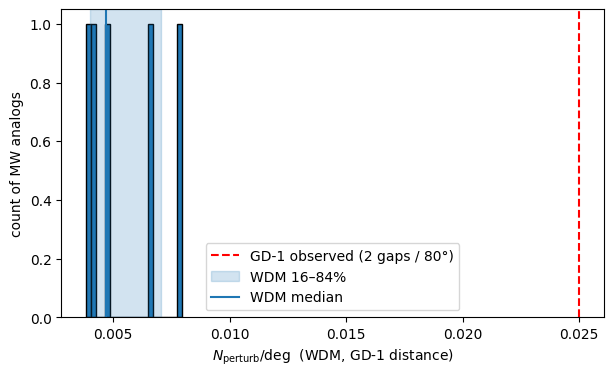

In [ ]:
comp_halos = [77, 85, 89, 90, 95]
pop = population_perturbation_rates(comp_halos, stream_distance_kpc=8.0, stream_age_gyr=3.0)

med = np.median(pop["per_deg"])
p16, p84 = np.percentile(pop["per_deg"], [16, 84])
print("WDM N_perturb/deg @ GD-1 (D=8 kpc, T=3 Gyr):")
print(f"  median = {med:.3g}")
print(f"  16-84% range = {p16:.3g} – {p84:.3g}")
print(
    f"  full range across {len(pop['per_deg'])} hosts:"
    f" {pop['per_deg'].min():.3g} – {pop['per_deg'].max():.3g}"
)

# Quick distribution plot
plt.figure(figsize=(7, 4))
plt.hist(pop["per_deg"], bins=20, edgecolor="k")
plt.axvline(2 / 80, color="red", ls="--", label="GD-1 observed (2 gaps / 80°)")
plt.axvspan(p16, p84, color="C0", alpha=0.2, label="WDM 16–84%")
plt.axvline(med, color="C0", label="WDM median")
plt.xlabel(r"$N_{\rm perturb}/{\rm deg}$  (WDM, GD-1 distance)")
plt.ylabel("count of MW analogs")
plt.legend()